In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
#Loading the dataset

data = pd.read_csv('../data/car_price_prediction.csv')

data.head(1)


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12


In [ ]:
#Exploring duplicates

data.duplicated().sum()

#There are 313 duplicates

np.int64(313)

In [ ]:
data["Levy"] = data["Levy"].replace("-", 0)
data["Levy"] = pd.to_numeric(data["Levy"])


data["Engine volume"] = data["Engine volume"].str.replace("Turbo","")
data["Engine volume"] = pd.to_numeric(data["Engine volume"])


data["Mileage"] = data["Mileage"].str.replace("km", '')
data["Mileage"]= pd.to_numeric(data["Mileage"])

#Transforming features to numeric so i can study them

In [ ]:
# #Exploring the dataset and information

print("Sample data :",data.sample(5))

print("Data information :",data.info())
print("Shape of the dataset :",data.shape)
print("Columns :",data.columns) 

data.isnull().sum()





#dataset contains no missing values , with datatypes of columns being either object or int64. , which is a continuous variable. The other columns are categorical variables, which will need to be encoded before training the model.








Sample data :              ID  Price  Levy Manufacturer      Model  Prod. year   Category  \
6813   45721228     30     0        HONDA        FIT        2003  Hatchback   
18748  45732898   7222   836      HYUNDAI     Sonata        2010      Sedan   
10321  45798280  13172     0        HONDA  Edix FR-v        2006  Universal   
17517  45772853   4547  1017          KIA     Avella        2017      Sedan   
6203   45642720    392   333         FORD     Fusion        2014      Sedan   

      Leather interior Fuel type  Engine volume  Mileage  Cylinders  \
6813                No    Petrol            1.3        0        4.0   
18748              Yes       LPG            2.0   112484        4.0   
10321              Yes    Diesel            2.2   300000        4.0   
17517              Yes    Petrol            2.0        0        4.0   
6203               Yes    Hybrid            2.0        0        4.0   

      Gear box type Drive wheels   Doors             Wheel   Color  Airbags  
6813  

In [ ]:
#Statistical summary & info
pd.set_option('display.float_format', '{:.2f}'.format)
display(data.describe())



#Price and mileage looks a bit awkward at max,std and mean, perhaps wrong values or considerable outliers.


,ID,Price,Levy,Prod. year,Engine volume,Mileage,Cylinders,Airbags
count,19237.00,19237.00,19237.00,19237.00,19237.00,19237.00,19237.00,19237.00
mean,45576535.89,18555.93,632.53,2010.91,2.31,1532235.69,4.58,6.58
std,936591.42,190581.27,567.72,5.67,0.88,48403869.38,1.20,4.32
min,20746880.00,1.00,0.00,1939.00,0.00,0.00,1.00,0.00
25%,45698374.00,5331.00,0.00,2009.00,1.80,70139.00,4.00,4.00
50%,45772308.00,13172.00,642.00,2012.00,2.00,126000.00,4.00,6.00
75%,45802036.00,22075.00,917.00,2015.00,2.50,188888.00,4.00,12.00
max,45816654.00,26307500.00,11714.00,2020.00,20.00,2147483647.00,16.00,16.00


ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

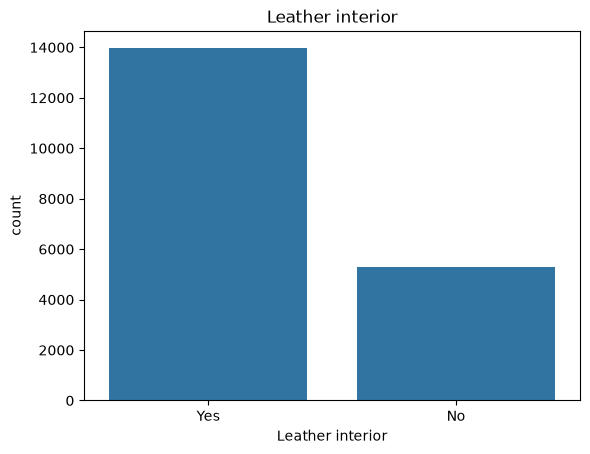

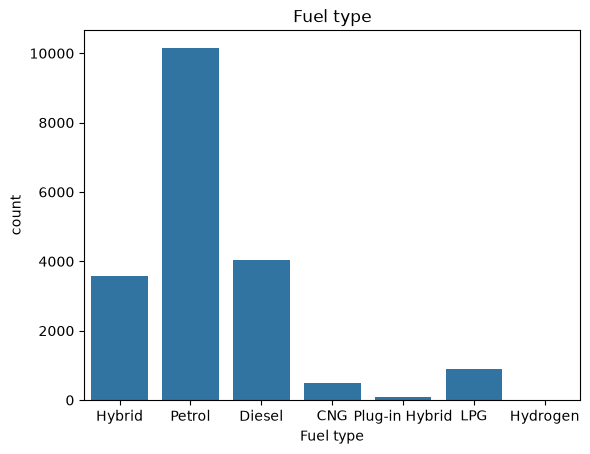

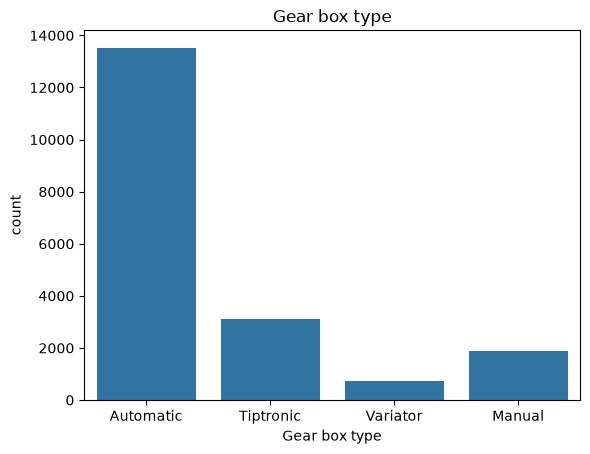

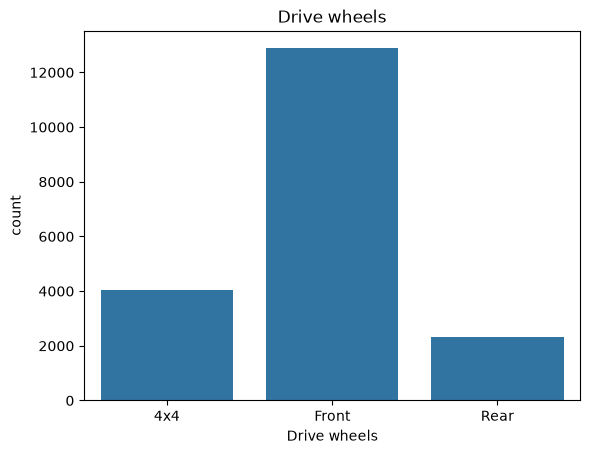

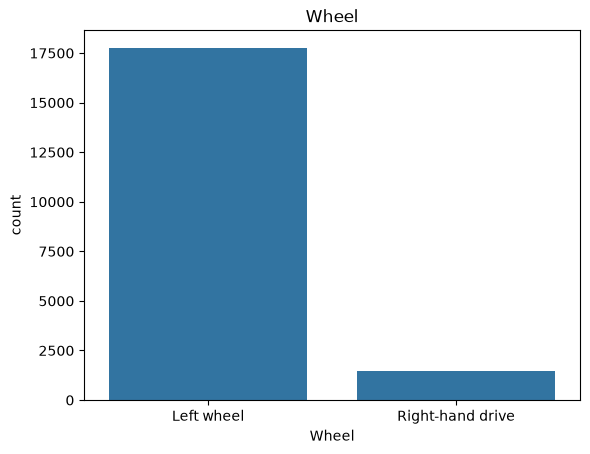

In [ ]:
#Analyzing every column and its distribution, outliers and relationship with the target variable.

for col in data.select_dtypes('number').columns:
    sns.kdeplot((data[col]))
    plt.show()
    sns.boxplot((data[col]))
    plt.show()

#Price , Levy and Mileage seems very highly skewed, perhaps some massive outliers. We will need to handle them before training the model
# we will try log transformation for now to take some ideas about normal distribution

for col in data.select_dtypes('number').columns:
    sns.kdeplot((np.log1p(data[col])))
    plt.show()
    sns.boxplot(np.log1p(data[col]))
    plt.show()


categories = data[["Leather interior","Fuel type","Gear box type","Drive wheels","Wheel"]]

for col in categories.columns:
    sns.countplot(x = data[col])
    plt.title(col)
    plt.show()

In [ ]:
#Identifying outliers in suspected columns
ouliers_col = data[["Price","Levy","Mileage"]]

# for col in ouliers_col.columns:
#     sns.boxplot(data[col])
#     plt.show()
#     sns.boxplot(np.log1p(data[col]))
#     plt.show()

#Very massive ouliers detected
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    outliers = df[(df[column] <= lower_bound) | (df[column] >= upper_bound)]
    
    return outliers[column]

detect_outliers(data,"Price")
detect_outliers(data,"Levy")
detect_outliers(data,"Mileage")


# Mileage,Levy and Price contains statistical outliers according to the extreme IQR methode.


56        87112
90        77775
111       85553
249       73071
316      100355
          ...  
18815    111002
18881    147397
18941     96263
19085     97219
19121     88438
Name: Price, Length: 305, dtype: int64

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
1225,45795524,627220,0,MERCEDES-BENZ,G 65 AMG 63AMG,2020,Jeep,Yes,Petrol,6.30,0,8.00,Tiptronic,4x4,04-May,Left wheel,Black,12


C:\Users\Hp\AppData\Local\Temp\ipykernel_18124\727248704.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(data.describe(include="object"))


,Manufacturer,Model,Category,Leather interior,Fuel type,Gear box type,Drive wheels,Doors,Wheel,Color
count,19237,19237,19237,19237,19237,19237,19237,19237,19237,19237
unique,65,1590,11,2,7,4,3,3,2,16
top,HYUNDAI,Prius,Sedan,Yes,Petrol,Automatic,Front,04-May,Left wheel,Black
freq,3769,1083,8736,13954,10150,13514,12874,18332,17753,5033


C:\Users\Hp\AppData\Local\Temp\ipykernel_18124\727248704.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data.select_dtypes('object').drop(columns=["Manufacturer","Model","Color","Category"]).columns:


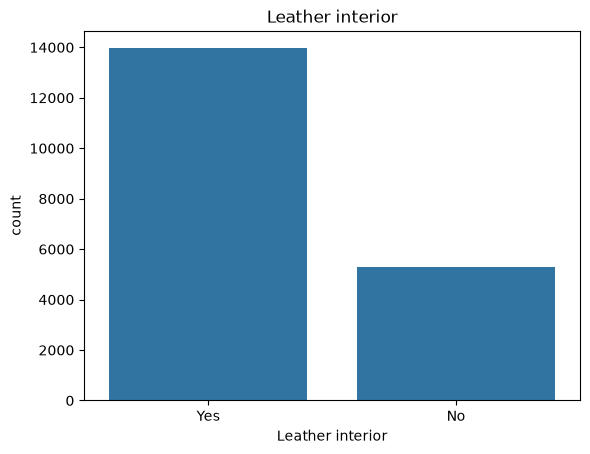

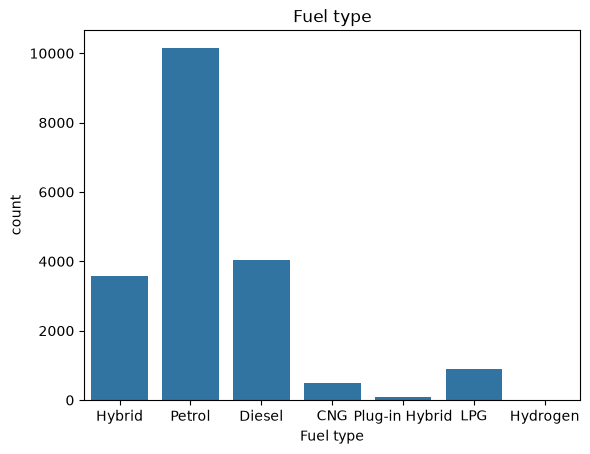

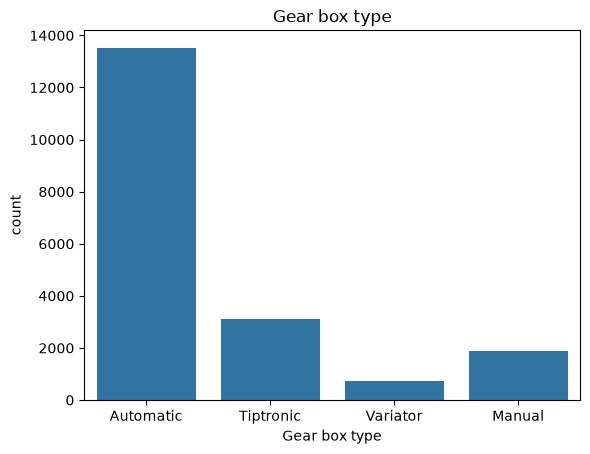

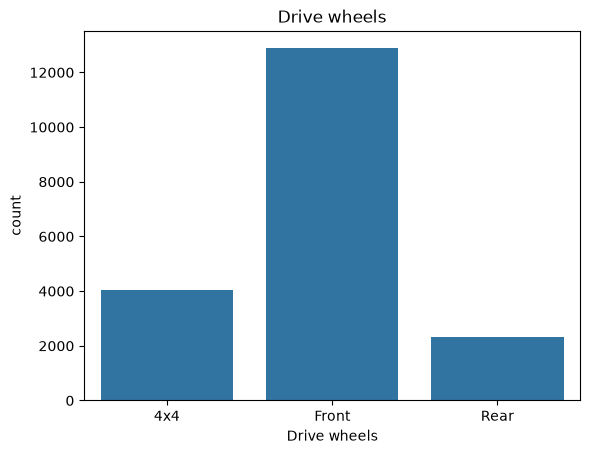

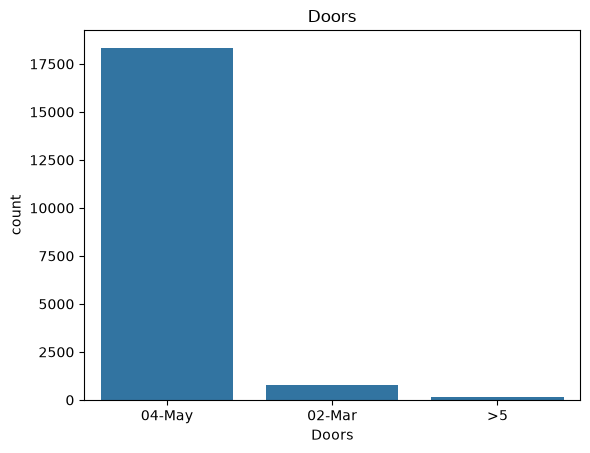

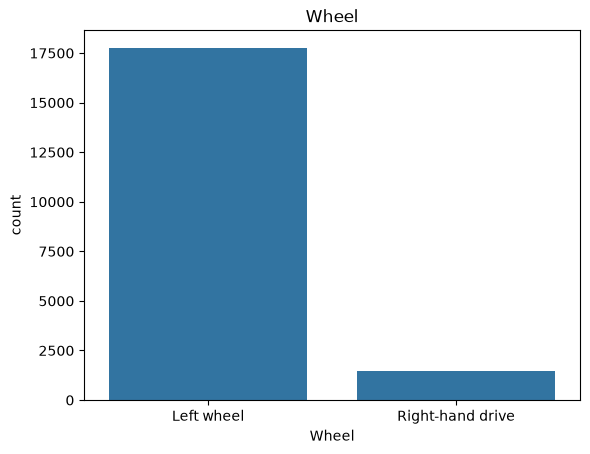

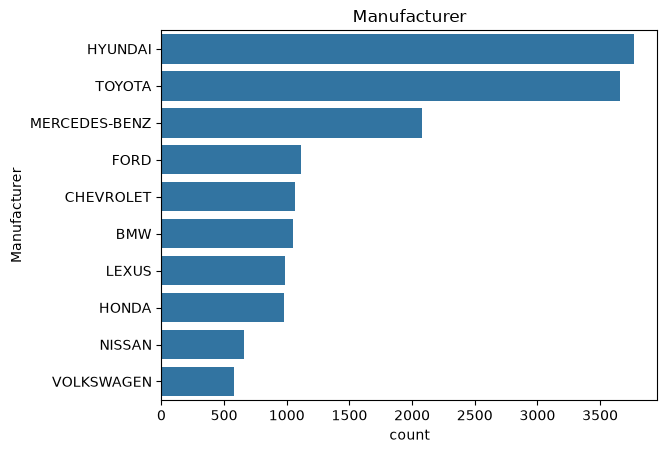

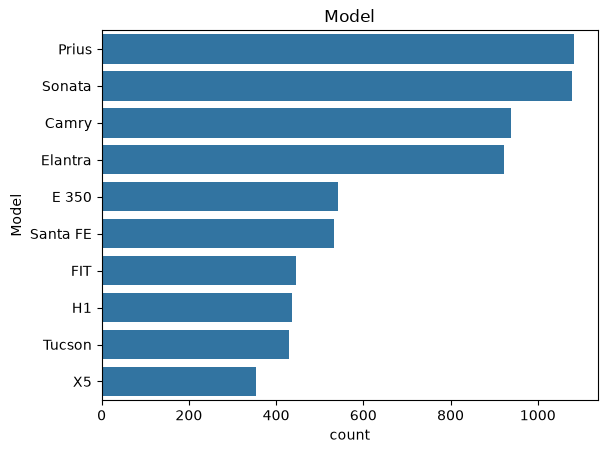

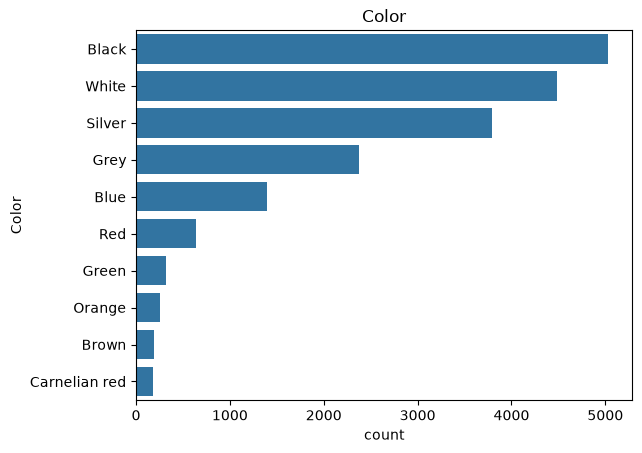

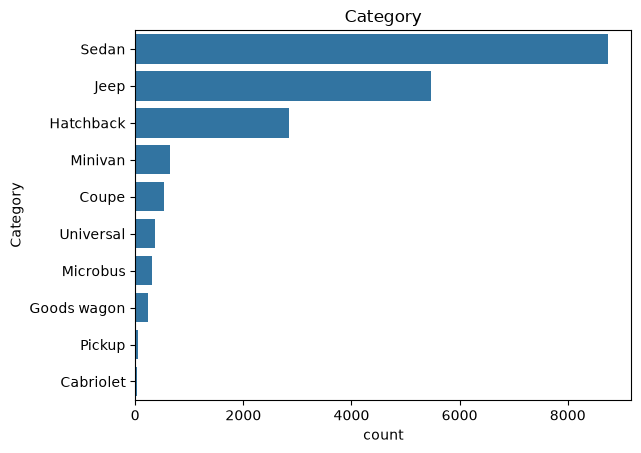

In [ ]:
#Ctegorical analysis
display(data.describe(include="object"))

for col in data.select_dtypes('object').drop(columns=["Manufacturer","Model","Color","Category"]).columns:
    sns.countplot(x = data[col])
    plt.title(col)
    plt.show()


col2 = data[["Manufacturer","Model","Color","Category"]]   
for col in col2.columns:
    sns.countplot(y = data[col],order=data[col].value_counts().head(10).index)
    plt.title(col)
    plt.show()

#This part shows the distribution of categorical variables and then draws the countplot of every variable , i divided the code 





In [ ]:
for col in data.select_dtypes('number').columns:
    print(col)
    print("Skewness:", data[col].skew())
    print("Kurtosis:", data[col].kurt())
    print()


#Most numerical features show noticeable skewness and high kurtosis, indicating non-normal distributions and the presence of extreme observations. Price and Mileage show particularly high values, suggesting that outliers have a strong influence on their distributions. These observations will be considered during the preprocessing stage    

ID
Skewness: -11.868234798415783
Kurtosis: 201.16124455547737

Price
Skewness: 136.4704265426872
Kurtosis: 18824.51732889934

Levy
Skewness: 2.3762219186515403
Kurtosis: 29.213355065218753

Prod. year
Skewness: -2.0822607659292505
Kurtosis: 11.329766009886956

Engine volume
Skewness: 2.1862419140120264
Kurtosis: 19.22258304125356

Mileage
Skewness: 38.89682127467136
Kurtosis: 1598.756423416571

Cylinders
Skewness: 2.091083485629857
Kurtosis: 6.486084824590528

Airbags
Skewness: 0.08201181063247334
Kurtosis: -1.334020582316455



<Axes: >

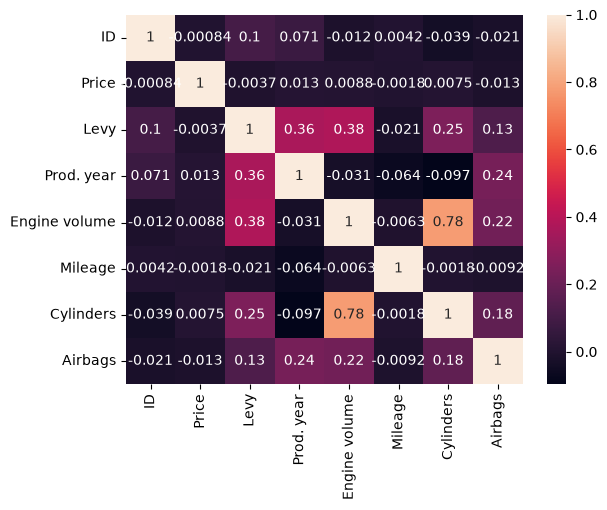

In [ ]:
#Studying correlation
numeric_data = data.select_dtypes('number')

numeric_data.corr()
sns.heatmap(numeric_data.corr(),annot=True)

#Most numerical features show weak linear correlations with Price. A strong correlation is observed between Engine volume and Cylinders, indicating that these two features are highly related



In [ ]:
#EDA Conclusions

# The dataset contains 19,237 observations and 18 features.
# No missing values were found in the dataset.
# The dataset contains both numerical and categorical features, with several categorical variables having a large number of unique values, particularly Model and Manufacturer.
# Price, Levy, and especially Mileage show strong skewness and extreme values, which may affect the model if they are not handled appropriately.
# The IQR analysis identified extreme statistical outliers in Price, Levy, and Mileage. These observations will be further evaluated and handled during the preprocessing stage.
# The categorical analysis shows that some categories are much more frequent than others. For high-cardinality features such as Manufacturer and Model, only the most frequent categories were visualized for better readability.
# The correlation analysis shows that most numerical features have weak linear correlations with Price.
# Engine volume and Cylinders show a relatively strong positive correlation (0.78), indicating that these two features are strongly related.
# Based on these findings, the next step is to clean and preprocess the data before building the prediction model